# FastRelax

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/kdidi/sphinx-docs/docs/tutorial/06_fast_relax.ipynb)

> **Prerequisite.** Complete [Packing and a Small Mutation Scan](04_packing_and_mutation_scan.ipynb) and [Minimization, constraints, and kinematics](05_minimization_constraints_kinematics.ipynb). FastRelax composes those packing and minimization primitives.

## Goals

This tutorial runs a deliberately small FastRelax example and explains the protocol rather than presenting it as an exact Rosetta port. You will:

- build the required `PackerPalette`, move map, and `FoldForest`;
- run one repeat on a checked-in 1UBQ slice;
- inspect the `fa_rep` and coordinate-constraint ramp;
- distinguish each stage's optimization weight from post-hoc full-weight rescoring;
- compare weighted score components and structures before and after relaxation;
- relax a four-member constrained ensemble in one GPU batch and click through every result; and
- see the verified adapter signature for optional kinematic minimization.

## Setup

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "kdidi/sphinx-docs/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol import beta2016_score_function
from tmol.io.pose_stack_from_biotite import pose_stack_from_biotite
from tmol.kinematics.fold_forest import FoldForest
from tmol.kinematics.move_map import CartesianMoveMap, MoveMap
from tmol.optimization.minimizers import run_cart_min, run_kin_min
from tmol.pack.packer_task import PackerPalette
from tmol.pose.pose_stack_builder import PoseStackBuilder
from tmol.relax.fast_relax import fast_relax
from tmol.score.constraint.utility import create_mainchain_coordinate_constraints
from tmol.score.score_types import ScoreType

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)

# Strictly a smoke-test budget shared by every minimizer in this tutorial,
# including the GPU batch. Finite output is not evidence of convergence.
TUTORIAL_MAX_ITER = 10


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def score_components_by_pose(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    weighted_terms = scorer(
        pose_stack.coords, sum_terms=False, apply_weights=True
    )
    score_types = score_function.all_score_types()
    constraint_index = next(
        index
        for index, score_type in enumerate(score_types)
        if score_type == ScoreType.constraint
    )
    constraint_scores = weighted_terms[constraint_index]
    non_constraint_scores = weighted_terms.sum(dim=0) - constraint_scores
    total_scores = weighted_terms.sum(dim=0)
    return [
        {
            "non_constraint_score_units": float(non_constraint_scores[i].detach().cpu()),
            "constraint_score_units": float(constraint_scores[i].detach().cpu()),
            "reported_total_score_units": float(total_scores[i].detach().cpu()),
        }
        for i in range(pose_stack.n_poses)
    ]


def score_components(pose_stack, score_function):
    if pose_stack.n_poses != 1:
        raise ValueError("Use score_components_by_pose() for batched PoseStacks.")
    return score_components_by_pose(pose_stack, score_function)[0]


def common_atom_mask(reference, mobile):
    return torch.isfinite(reference.coords).all(dim=-1) & torch.isfinite(
        mobile.coords
    ).all(dim=-1)


def rms_displacement(reference, mobile):
    """Raw all-atom RMS displacement in the input coordinate frame."""
    mask = common_atom_mask(reference, mobile)
    delta = mobile.coords[mask] - reference.coords[mask]
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def kabsch_aligned_rmsd(reference, mobile):
    """All-atom RMSD after least-squares rigid-body superposition."""
    mask = common_atom_mask(reference, mobile)
    reference_xyz = reference.coords[mask]
    mobile_xyz = mobile.coords[mask]
    reference_centered = reference_xyz - reference_xyz.mean(dim=0)
    mobile_centered = mobile_xyz - mobile_xyz.mean(dim=0)
    covariance = mobile_centered.T @ reference_centered
    u, _, vh = torch.linalg.svd(covariance)
    handedness = torch.sign(torch.det(u @ vh))
    correction = torch.eye(3, device=mobile_xyz.device, dtype=mobile_xyz.dtype)
    correction[-1, -1] = handedness
    rotation = u @ correction @ vh
    delta = mobile_centered @ rotation - reference_centered
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def declared_mainchain_atom_mask(pose_stack):
    """Select atoms named in each residue type's TMol polymer declaration."""
    mask = torch.zeros_like(pose_stack.real_atoms)
    atom_names = []
    seen_atom_names = set()
    for pose_index in range(pose_stack.n_poses):
        for block_index in range(pose_stack.max_n_blocks):
            block_type_index = int(
                pose_stack.block_type_ind64[pose_index, block_index].item()
            )
            if block_type_index < 0:
                continue
            block_type = pose_stack.packed_block_types.active_block_types[
                block_type_index
            ]
            polymer = block_type.properties.polymer
            if polymer is None:
                continue
            atom_offset = int(
                pose_stack.block_coord_offset64[pose_index, block_index].item()
            )
            for atom_name in polymer.mainchain_atoms:
                atom_index = atom_offset + block_type.atom_to_idx[atom_name]
                if bool(pose_stack.real_atoms[pose_index, atom_index]):
                    mask[pose_index, atom_index] = True
                    if atom_name not in seen_atom_names:
                        atom_names.append(atom_name)
                        seen_atom_names.add(atom_name)
    return mask, tuple(atom_names)


def coordinates_equal(first, second):
    if first.coords.shape != second.coords.shape:
        return False
    first_finite = torch.isfinite(first.coords)
    second_finite = torch.isfinite(second.coords)
    return (
        torch.equal(first.block_type_ind64, second.block_type_ind64)
        and torch.equal(first_finite, second_finite)
        and torch.equal(first.coords[first_finite], second.coords[second_finite])
    )

## Protocol and ramp schedule

TMol's `fast_relax(pose_stack, sfxn, packer_pallete, move_map, fold_forest, *, ...)` alternates rotamer packing and minimization. Each schedule entry independently scales the starting `fa_rep` weight for packing and minimization and can scale the starting coordinate-constraint weight. Explicit `cst_frac` values in dictionary entries define the ramp directly; automatic constraint ramping matters for schedule entries that omit them. The final minimization fraction should be `1.0` so the accepted structure is evaluated with full repulsion.

The production default is a four-step, two-repeat MonomerRelax2019-derived schedule. This tutorial uses two steps, one repeat, and `TUTORIAL_MAX_ITER=10` for every Cartesian or kinematic minimization to keep the checked-in example and CPU smoke test small. Ten iterations are strictly a smoke-test budget: finite output or a favorable score change must not be equated with convergence. The optimizer's normal default is 200 iterations, but production work must establish convergence for its own system and question.

The coordinate helper restrains each residue type's TMol-declared main-chain atoms. For the standard amino acids here those are N, CA, and C—not O—with sigma 0.5 Å. This tutorial uses constraint weight 1.0 intentionally; it is stronger than the usual Rosetta comparison weight of 0.5. The next cell reports the actual names, count, sigma, and weight.

TMol's default `min_fn=None` selects Cartesian minimization, so the workflow passes a `CartesianMoveMap`. The `FoldForest` remains a required protocol argument but is ignored by the Cartesian adapter; it becomes active for the optional kinematic adapter below.

In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 6)]
setup_diagnostics = StringIO()
try:
    with redirect_stdout(setup_diagnostics), redirect_stderr(setup_diagnostics):
        pose = pose_stack_from_biotite(protein_slice, device, no_optH=True)
        relax_start = create_mainchain_coordinate_constraints(pose)
except Exception:
    print(setup_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fa_rep_start = float(score_function.get_weight(ScoreType.fa_ljrep))
constraint_start = float(score_function.get_weight(ScoreType.constraint))
mainchain_mask, restrained_atom_names = declared_mainchain_atom_mask(relax_start)
CONSTRAINT_SIGMA_A = 0.5

palette = PackerPalette()
cartesian_move_map = CartesianMoveMap()
fold_forest = FoldForest.reasonable_fold_forest(relax_start)
tiny_schedule = [
    {"fa_rep_pack_frac": 0.10, "fa_rep_min_frac": 0.20, "cst_frac": 1.0},
    {"fa_rep_pack_frac": 1.00, "fa_rep_min_frac": 1.00, "cst_frac": 0.0},
]

schedule_table = pd.DataFrame(tiny_schedule)
schedule_table["fa_rep_pack_weight"] = (
    schedule_table["fa_rep_pack_frac"] * fa_rep_start
)
schedule_table["fa_rep_min_weight"] = (
    schedule_table["fa_rep_min_frac"] * fa_rep_start
)
schedule_table["constraint_weight"] = schedule_table["cst_frac"] * constraint_start
print("input:", cif_path.name)
print("coordinate-restraint atom names:", ", ".join(restrained_atom_names))
print("coordinate-restraint count:", int(mainchain_mask.sum().item()))
print(f"coordinate-restraint sigma: {CONSTRAINT_SIGMA_A:.1f} Å")
print(f"coordinate-restraint score weight: {constraint_start:.1f}")
print("O is not TMol-declared main chain here and is not constrained.")
print("Weight 1.0 is intentional; Rosetta comparisons commonly use 0.5.")
show_table(schedule_table)

input: 1UBQ.cif
coordinate-restraint atom names: N, CA, C
coordinate-restraint count: 18
coordinate-restraint sigma: 0.5 Å
coordinate-restraint score weight: 1.0
O is not TMol-declared main chain here and is not constrained.
Weight 1.0 is intentional; Rosetta comparisons commonly use 0.5.


## Run one repeat

The schedule table should show low repulsion in the first stage and full repulsion in the final stage, while the coordinate-constraint weight ramps to zero. If the constraint column is zero in every row, check both the score-function constraint weight and the pose's attached `ConstraintSet`.

The call below uses the complete current signature: pose, score function, palette, move map, and fold forest are positional; protocol controls are keyword-only. Coordinate constraints are already attached to `relax_start`, and the score function has a non-zero constraint weight, so the explicit `cst_frac` values in the schedule are active. The custom adapter keeps `max_iter` equal to the tutorial-wide smoke-test value and records the constraint weight and objective immediately before and after each minimization stage. These objective changes diagnose the short run; they are not convergence certificates.

In [4]:
def tutorial_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    del fold_forest
    coord_mask = move_map.coord_mask if isinstance(move_map, CartesianMoveMap) else None
    return run_cart_min(
        pose_stack,
        stage_score_function,
        coord_mask=coord_mask,
        verbose=verbose,
        optimizer_kwargs={
            "max_iter": TUTORIAL_MAX_ITER,
            "verbose": verbose,
        },
    )


relax_stage_records = []


def recording_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    constraint_weight = float(
        stage_score_function.get_weight(ScoreType.constraint)
    )
    objective_before = score_components(
        pose_stack, stage_score_function
    )["reported_total_score_units"]
    minimized = tutorial_cart_min(
        pose_stack,
        stage_score_function,
        fold_forest=fold_forest,
        move_map=move_map,
        verbose=verbose,
    )
    objective_after = score_components(
        minimized, stage_score_function
    )["reported_total_score_units"]
    relax_stage_records.append(
        {
            "pose": minimized.clone(),
            "constraint_weight_at_optimization": constraint_weight,
            "objective_before_min_units": objective_before,
            "objective_after_min_units": objective_after,
            "objective_change_during_min_units": objective_after - objective_before,
        }
    )
    return minimized


print(
    f"smoke-test optimizer max_iter: {TUTORIAL_MAX_ITER} "
    "(convergence not assessed)"
)
before_components = score_components(relax_start, score_function)
TUTORIAL_NUM_REPEATS = 1
relaxed = fast_relax(
    relax_start,
    score_function,
    palette,
    cartesian_move_map,
    fold_forest,
    num_repeats=TUTORIAL_NUM_REPEATS,
    schedule=tiny_schedule,
    ramp_constraints=True,
    min_fn=recording_cart_min,
    verbose=False,
)
after_components = score_components(relaxed, score_function)

if coordinates_equal(relaxed, relax_start):
    accepted_from = "input"
else:
    accepted_from = "unresolved (not an exact recorded repeat endpoint)"
    for repeat_index in range(TUTORIAL_NUM_REPEATS):
        record_index = (repeat_index + 1) * len(tiny_schedule) - 1
        if coordinates_equal(relaxed, relax_stage_records[record_index]["pose"]):
            accepted_from = (
                f"repeat {repeat_index + 1} endpoint "
                f"(stage {record_index + 1})"
            )
            break

score_frame = pd.DataFrame(
    [
        {
            "structure": "before",
            "accepted_from": "not applicable",
            **before_components,
        },
        {
            "structure": "accepted final",
            "accepted_from": accepted_from,
            **after_components,
        },
    ]
)
for component in (
    "non_constraint_score_units",
    "constraint_score_units",
    "reported_total_score_units",
):
    score_frame[f"{component.removesuffix('_units')}_change_units"] = (
        score_frame[component] - before_components[component]
    )
score_frame["finite_smoke_test_output"] = np.isfinite(
    score_frame[
        [
            "non_constraint_score_units",
            "constraint_score_units",
            "reported_total_score_units",
        ]
    ]
).all(axis=1)
score_frame["convergence_status"] = "not assessed (10-iteration smoke test)"
print("accepted final source:", accepted_from)
show_table(score_frame)

smoke-test optimizer max_iter: 10 (convergence not assessed)


accepted final source: repeat 1 endpoint (stage 2)


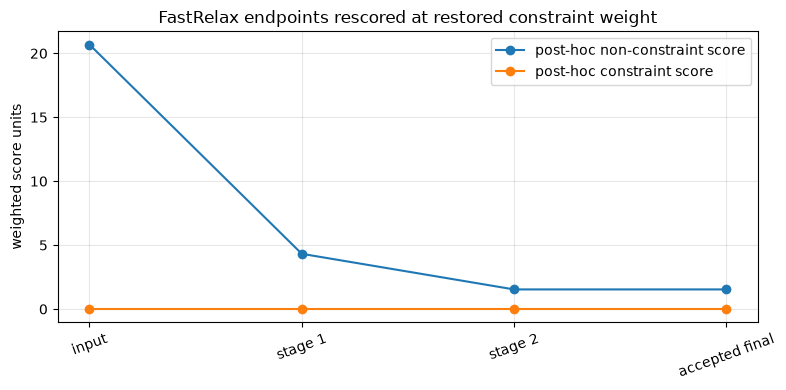

In [5]:
trajectory_structures = {"input": relax_start}
stage_metadata = {
    "input": {
        "constraint_weight_at_optimization": np.nan,
        "objective_before_min_units": np.nan,
        "objective_after_min_units": np.nan,
        "objective_change_during_min_units": np.nan,
    }
}
for stage_index, record in enumerate(relax_stage_records):
    label = f"stage {stage_index + 1}"
    trajectory_structures[label] = record["pose"]
    stage_metadata[label] = record
trajectory_structures["accepted final"] = relaxed
stage_metadata["accepted final"] = {
    "constraint_weight_at_optimization": np.nan,
    "objective_before_min_units": np.nan,
    "objective_after_min_units": np.nan,
    "objective_change_during_min_units": np.nan,
}

# fast_relax restores the starting constraint weight before returning. These
# scores are therefore a common post-hoc decomposition, not each stage's
# historical optimization objective.
posthoc_constraint_weight = float(
    score_function.get_weight(ScoreType.constraint)
)
trajectory_rows = []
trajectory_notes = {}
for frame_index, (label, frame_pose) in enumerate(trajectory_structures.items()):
    components = score_components(frame_pose, score_function)
    metadata = stage_metadata[label]
    raw_displacement = rms_displacement(relax_start, frame_pose)
    aligned_rmsd = kabsch_aligned_rmsd(relax_start, frame_pose)
    trajectory_rows.append(
        {
            "frame": frame_index,
            "label": label,
            "accepted_from": accepted_from if label == "accepted final" else "",
            "constraint_weight_at_optimization": metadata[
                "constraint_weight_at_optimization"
            ],
            "objective_before_min_units": metadata[
                "objective_before_min_units"
            ],
            "objective_after_min_units": metadata[
                "objective_after_min_units"
            ],
            "objective_change_during_min_units": metadata[
                "objective_change_during_min_units"
            ],
            "constraint_weight_for_posthoc_rescore": posthoc_constraint_weight,
            "raw_RMS_displacement_from_input_A": raw_displacement,
            "Kabsch_RMSD_from_input_A": aligned_rmsd,
            **components,
        }
    )
    optimized_weight = metadata["constraint_weight_at_optimization"]
    optimized_text = (
        "not a minimization endpoint"
        if np.isnan(optimized_weight)
        else (
            f"optimized cst weight {optimized_weight:.3f}; min objective change "
            f"{metadata['objective_change_during_min_units']:+.3f}"
        )
    )
    acceptance_text = (
        f"; accepted from {accepted_from}" if label == "accepted final" else ""
    )
    trajectory_notes[label] = (
        f"{optimized_text}; post-hoc non-constraint "
        f"{components['non_constraint_score_units']:.3f}; "
        f"constraint {components['constraint_score_units']:.3f}; "
        f"raw/aligned {raw_displacement:.3f}/{aligned_rmsd:.3f} Å"
        f"{acceptance_text}"
    )
trajectory_frame = pd.DataFrame(trajectory_rows)
show_table(trajectory_frame)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["non_constraint_score_units"],
    marker="o",
    label="post-hoc non-constraint score",
)
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["constraint_score_units"],
    marker="o",
    label="post-hoc constraint score",
)
ax.set(
    xticks=trajectory_frame["frame"],
    xticklabels=trajectory_frame["label"],
    ylabel="weighted score units",
    title="FastRelax endpoints rescored at restored constraint weight",
)
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(
    tmol.switchable_view(
        trajectory_structures,
        notes=trajectory_notes,
    )
)

**Expected observations.** The non-constraint and constraint components, score changes, and structural metrics must be finite. “Non-constraint” is the exact description: it includes every weighted beta2016 term except the coordinate-constraint term, including empirical/statistical contributions. All reported values are weighted TMol score units, not kcal/mol. The raw metric retains coordinate-frame motion; Kabsch RMSD removes the best rigid-body superposition.

`fast_relax()` restores the starting constraint weight before returning. The table records the weight and objective change present during each stage's minimization separately from the restored weight used for the common post-hoc score decomposition. In particular, the final stage is optimized with `cst_frac=0`, but its displayed constraint penalty is recalculated afterward at full starting weight; it diagnoses restraint violation and is not part of that stage's optimization objective. The structure switcher records minimization endpoints for each pack/min stage and the final accept-to-best result; it does not contain LBFGS line-search evaluations or internal packing trajectories.

TMol's accept-best pool is **input-inclusive**: it initializes the best pose from the unrelaxed input and, after each complete schedule repeat, accepts that repeat endpoint only when its score is strictly lower. It does not accept among every intermediate stage. Consequently, a one-repeat run can legitimately return the exact input, and `accepted_from` explicitly distinguishes that case from the recorded repeat endpoint. This differs from Rosetta's usual FastRelax comparison among relaxed repeat outputs, where the unrelaxed input is not normally retained as an accept-best candidate.

There is an important custom-schedule caveat: the initial best score is captured with the weights present at protocol start, whereas `accept_best` scores a repeat endpoint with the weights left by the final schedule step. The tiny schedule here ends at full repulsion and zero constraint weight, and its restraints are built from the input coordinates, which masks that mismatch for this demonstration. For a custom schedule or initially violated restraints, rescore the input and repeat endpoints under one fixed weight set before interpreting which structure is better.

A tiny pedagogical schedule is not guaranteed to improve every input. Large distortions, NaNs, or a missing ligand/residue are failures, not expected stochastic variation. Conversely, finite output or a favorable objective change under `max_iter=10` is only smoke-test evidence; convergence is not assessed.

## Optional kinematic minimizer

`fast_relax` calls a custom minimizer as `min_fn(pose_stack, sfxn, *, fold_forest, move_map, verbose)`. The adapter below uses the verified `run_kin_min(pose_stack, sfxn, ff, mm, ...)` signature and the same tutorial iteration limit. To use it, supply a `MoveMap` (not a `CartesianMoveMap`) and pass `min_fn=kinematic_min_fn` to `fast_relax`.

This adapter is defined but not invoked because doing so would duplicate the full packing schedule with a different minimizer. Notebook 05 executes both Cartesian and kinematic minimization directly; use that comparison before enabling the more expensive FastRelax variant here.

In [6]:
def kinematic_min_fn(
    pose_stack, score_function, *, fold_forest, move_map, verbose
):
    return run_kin_min(
        pose_stack,
        score_function,
        fold_forest,
        move_map,
        optimizer_kwargs={
            "max_iter": TUTORIAL_MAX_ITER,
            "verbose": verbose,
        },
        verbose=verbose,
    )


kinematic_move_map = MoveMap.from_pose_stack(relax_start)
kinematic_move_map.move_all_named_torsions = True
kinematic_move_map.move_all_jumps = False
kinematic_move_map.move_all_root_jumps = False
# Example extension (not run here):
# kin_relaxed = fast_relax(
#     relax_start, score_function, palette, kinematic_move_map, fold_forest,
#     num_repeats=1, schedule=tiny_schedule, min_fn=kinematic_min_fn,
# )

## Relax an ensemble in one GPU batch

The single-structure call above and the batched call below use the same constrained protocol: each perturbed input receives main-chain coordinate constraints, the ensemble score function starts with the same nonzero constraint weight, the same two-stage schedule is used, and every minimization uses `TUTORIAL_MAX_ITER`. Four reproducibly perturbed conformations are assembled into one `PoseStack`, relaxed together, scored with the same constraint/non-constraint decomposition, and split after the batched protocol for per-member metrics and the labeled structure switcher. This exposes the batch dimension to GPU kernels; measure it against four serial calls on the target GPU before choosing a production batch size.

Constraints are constructed after perturbation, so each ensemble member is restrained to its own starting TMol-declared N/CA/C coordinates, exactly as the single structure is restrained to its own start; O is not constrained. The results report per-member score changes, raw displacement, Kabsch-aligned RMSD, and whether accept-best retained that member's input or the recorded repeat endpoint. The cell is marked `gpu-only`: the GPU documentation stage executes it for the rendered page, while the ordinary CPU smoke path records an explicit skip. The Colab button remains the way to rerun it on another GPU.

In [7]:
#| tags: [gpu-only]
if device.type != "cuda":
    print("Skipped: open this notebook in a Colab GPU runtime to run batch relax.")
else:
    ensemble_members = {}
    for member_index, noise_scale in enumerate((0.00, 0.01, 0.02, 0.03)):
        member = pose.clone()
        generator = torch.Generator(device=device).manual_seed(SEED + member_index)
        noise = torch.randn(
            member.coords.shape,
            generator=generator,
            device=device,
            dtype=member.coords.dtype,
        )
        member.coords[member.real_atoms] += noise[member.real_atoms] * noise_scale
        ensemble_members[f"input {member_index}"] = member

    ensemble = PoseStackBuilder.from_poses(
        list(ensemble_members.values()), device
    )
    ensemble = create_mainchain_coordinate_constraints(ensemble)
    ensemble_fold_forest = FoldForest.reasonable_fold_forest(ensemble)
    ensemble_sfxn = beta2016_score_function(device)
    ensemble_sfxn.set_weight(ScoreType.constraint, constraint_start)
    ensemble_before = score_components_by_pose(ensemble, ensemble_sfxn)
    ensemble_stage_records = []

    def recording_ensemble_cart_min(
        pose_stack, stage_score_function, *, fold_forest, move_map, verbose
    ):
        minimized = tutorial_cart_min(
            pose_stack,
            stage_score_function,
            fold_forest=fold_forest,
            move_map=move_map,
            verbose=verbose,
        )
        ensemble_stage_records.append(minimized.clone())
        return minimized

    relaxed_ensemble = fast_relax(
        ensemble,
        ensemble_sfxn,
        PackerPalette(),
        CartesianMoveMap(),
        ensemble_fold_forest,
        num_repeats=1,
        schedule=tiny_schedule,
        ramp_constraints=True,
        min_fn=recording_ensemble_cart_min,
        verbose=False,
    )
    ensemble_after = score_components_by_pose(
        relaxed_ensemble, ensemble_sfxn
    )

    ensemble_rows = []
    ensemble_accepted_from = {}
    for member_index in range(ensemble.n_poses):
        before_pose = ensemble.split(member_index)
        after_pose = relaxed_ensemble.split(member_index)
        endpoint_pose = ensemble_stage_records[-1].split(member_index)
        if coordinates_equal(after_pose, before_pose):
            member_accepted_from = "input"
        elif coordinates_equal(after_pose, endpoint_pose):
            member_accepted_from = "repeat 1 endpoint (stage 2)"
        else:
            member_accepted_from = "unresolved"
        ensemble_accepted_from[member_index] = member_accepted_from
        raw_after = rms_displacement(before_pose, after_pose)
        aligned_after = kabsch_aligned_rmsd(before_pose, after_pose)
        before = ensemble_before[member_index]
        after = ensemble_after[member_index]
        ensemble_rows.extend(
            [
                {
                    "member": member_index,
                    "structure": "before",
                    "accepted_from": "not applicable",
                    "raw_RMS_displacement_A": 0.0,
                    "Kabsch_RMSD_A": 0.0,
                    "non_constraint_score_change_units": 0.0,
                    "constraint_score_change_units": 0.0,
                    "objective_change_units": 0.0,
                    **before,
                },
                {
                    "member": member_index,
                    "structure": "accepted final",
                    "accepted_from": member_accepted_from,
                    "raw_RMS_displacement_A": raw_after,
                    "Kabsch_RMSD_A": aligned_after,
                    "non_constraint_score_change_units": (
                        after["non_constraint_score_units"]
                        - before["non_constraint_score_units"]
                    ),
                    "constraint_score_change_units": (
                        after["constraint_score_units"]
                        - before["constraint_score_units"]
                    ),
                    "objective_change_units": (
                        after["reported_total_score_units"]
                        - before["reported_total_score_units"]
                    ),
                    **after,
                },
            ]
        )
    ensemble_frame = pd.DataFrame(ensemble_rows)
    ensemble_frame["finite_smoke_test_output"] = np.isfinite(
        ensemble_frame[
            [
                "reported_total_score_units",
                "raw_RMS_displacement_A",
                "Kabsch_RMSD_A",
            ]
        ]
    ).all(axis=1)
    ensemble_frame["convergence_status"] = (
        "not assessed (10-iteration smoke test)"
    )
    show_table(ensemble_frame)

    comparison_structures = {}
    comparison_notes = {}
    for member_index in range(ensemble.n_poses):
        before_label = f"member {member_index} — before"
        after_label = f"member {member_index} — after"
        comparison_structures[before_label] = ensemble.split(member_index)
        comparison_structures[after_label] = relaxed_ensemble.split(member_index)
        before = ensemble_before[member_index]
        after = ensemble_after[member_index]
        comparison_notes[before_label] = (
            f"non-constraint {before['non_constraint_score_units']:.3f}; "
            f"constraint {before['constraint_score_units']:.3f} score units; "
            "raw/aligned 0.000/0.000 Å"
        )
        comparison_notes[after_label] = (
            f"non-constraint {after['non_constraint_score_units']:.3f}; "
            f"constraint {after['constraint_score_units']:.3f}; "
            f"raw/aligned "
            f"{rms_displacement(ensemble.split(member_index), relaxed_ensemble.split(member_index)):.3f}/"
            f"{kabsch_aligned_rmsd(ensemble.split(member_index), relaxed_ensemble.split(member_index)):.3f} Å; "
            f"accepted from {ensemble_accepted_from[member_index]}"
        )
    display(
        tmol.switchable_view(
            comparison_structures,
            notes=comparison_notes,
        )
    )

## Rosetta comparison

Both protocols alternate side-chain repacking with minimization while ramping steric repulsion, and both can ramp coordinate constraints. A common Rosetta FastRelax workflow minimizes torsional degrees of freedom through a `MoveMap` unless Cartesian minimization is explicitly selected. TMol's current `fast_relax` default is Cartesian (`min_fn=None` selects its Cartesian adapter); torsional minimization requires the explicit callable and `MoveMap` shown above. This changes the active degrees of freedom and can change the resulting trajectory.

Rosetta FastRelax has a mature script language, MoveMap factories, symmetry and membrane integrations, and many protocol options. TMol implements a smaller tensor-native subset: a Python schedule, `PackerTask` operations, the Cartesian default plus an optional callable minimizer, and accept-to-best across repeats.

The algorithms and score functions are not numerically interchangeable. Treat TMol FastRelax as partial protocol parity for batched refinement, not as an exact port or a guarantee of reproducing Rosetta trajectories.

## Exercises

1. Replace the tiny schedule with `DEFAULT_RELAX_SCHEDULE` and compare runtime and score.
2. Keep constraints active in the final step and compare Cα displacement.
3. Pass `kinematic_min_fn` with the prepared `kinematic_move_map` and compare Cartesian and kinematic results.
4. Write a task operation that restricts packing to a selected block mask.
5. Batch two small poses, then rescore the input and repeat endpoints under one fixed weight set before interpreting accept-to-best behavior per pose.

## References

- [Rosetta Relax tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Relax_Tutorial/Relax)
- [Rosetta FastRelax implementation](https://github.com/RosettaCommons/rosetta/blob/main/source/src/protocols/relax/FastRelax.cc)
- [PyRosetta packing, design, and regional relax](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb)
- [PyRosetta refinement documentation](https://www.pyrosetta.org/documentation)